<a href="https://colab.research.google.com/github/A-Ohanusi/Credit-Risk-Model-for-Lending-Against-Bitcoin-Collateral/blob/main/heston_vs_jump_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INITIAL_PRICE = 60442.10156
YEARS = 1
STEPS = 365
SIMULATIONS = 5000
SEED = 42

In [ ]:
def simulate_merton_jump_diffusion(
    initial_price,
    mu,
    sigma,
    jump_intensity,
    jump_mean,
    jump_std,
    years=1,
    steps=365,
    simulations=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    dt = years / steps

    paths = np.zeros((steps + 1, simulations))
    paths[0] = initial_price

    jump_compensator = (
        np.exp(jump_mean + 0.5 * jump_std**2) - 1
    )

    for t in range(1, steps + 1):
        z = rng.normal(size=simulations)

        jump_counts = rng.poisson(
            jump_intensity * dt,
            size=simulations
        )

        jump_sizes = np.zeros(simulations)

        active = jump_counts > 0

        jump_sizes[active] = rng.normal(
            loc=jump_counts[active] * jump_mean,
            scale=np.sqrt(jump_counts[active]) * jump_std
        )

        diffusion = (
            mu
            - 0.5 * sigma**2
            - jump_intensity * jump_compensator
        ) * dt + sigma * np.sqrt(dt) * z

        paths[t] = paths[t - 1] * np.exp(
            diffusion + jump_sizes
        )

    return paths

In [ ]:
def simulate_heston_paths(
    initial_price,
    initial_variance,
    mu,
    kappa,
    theta,
    xi,
    rho,
    years=1,
    steps=365,
    simulations=1000,
    seed=42
):
    if initial_price <= 0:
        raise ValueError("Initial price must be positive.")

    if initial_variance < 0:
        raise ValueError("Initial variance cannot be negative.")

    rng = np.random.default_rng(seed)

    dt = years / steps

    prices = np.zeros((steps + 1, simulations))
    variances = np.zeros((steps + 1, simulations))

    prices[0] = initial_price
    variances[0] = initial_variance

    for t in range(1, steps + 1):
        z_price = rng.normal(size=simulations)
        z_independent = rng.normal(size=simulations)

        z_variance = (
            rho * z_price
            + np.sqrt(1 - rho**2) * z_independent
        )

        previous_variance = np.maximum(
            variances[t - 1],
            0
        )

        variances[t] = (
            variances[t - 1]
            + kappa
            * (theta - previous_variance)
            * dt
            + xi
            * np.sqrt(previous_variance * dt)
            * z_variance
        )

        variances[t] = np.maximum(
            variances[t],
            0
        )

        prices[t] = prices[t - 1] * np.exp(
            (
                mu
                - 0.5 * previous_variance
            ) * dt
            + np.sqrt(previous_variance * dt)
            * z_price
        )

    return prices, variances

In [ ]:
jump_paths = simulate_merton_jump_diffusion(
    initial_price=INITIAL_PRICE,
    mu=0.3652811096366128,
    sigma=0.5422935118740928,
    jump_intensity=6.702641752577319,
    jump_mean=-0.027402239469623824,
    jump_std=0.13690701827327986,
    years=YEARS,
    steps=STEPS,
    simulations=SIMULATIONS,
    seed=SEED
)

heston_paths, heston_variance_paths = simulate_heston_paths(
    initial_price=INITIAL_PRICE,
    initial_variance=0.15174189489216258,
    mu=0.21229669319699437,
    kappa=6.339505720539599,
    theta=0.3838226395419708,
    xi=2.0635870038271733,
    rho=-0.19109528493954064,
    years=YEARS,
    steps=STEPS,
    simulations=SIMULATIONS,
    seed=SEED
)

In [ ]:
jump_terminal = jump_paths[-1]
heston_terminal = heston_paths[-1]

In [ ]:
def model_summary(terminal_prices, initial_price):
    return {
        "Mean terminal price": terminal_prices.mean(),
        "Median terminal price": np.median(terminal_prices),
        "5th percentile": np.percentile(terminal_prices, 5),
        "1st percentile": np.percentile(terminal_prices, 1),
        "Probability of 20% fall": np.mean(
            terminal_prices < initial_price * 0.80
        ),
        "Probability of 40% fall": np.mean(
            terminal_prices < initial_price * 0.60
        ),
        "Probability of 60% fall": np.mean(
            terminal_prices < initial_price * 0.40
        ),
        "Probability of 80% fall": np.mean(
            terminal_prices < initial_price * 0.20
        )
    }

jump_summary = model_summary(
    jump_terminal,
    INITIAL_PRICE
)

heston_summary = model_summary(
    heston_terminal,
    INITIAL_PRICE
)

comparison = pd.DataFrame({
    "Jump Diffusion": jump_summary,
    "Heston": heston_summary
})

comparison

,Jump Diffusion,Heston
Mean terminal price,87734.148642,75640.820561
Median terminal price,71021.474233,65324.322202
5th percentile,23844.792798,21951.020023
1st percentile,15356.563954,12202.281959
Probability of 20% fall,0.269600,0.308200
Probability of 40% fall,0.152200,0.171200
Probability of 60% fall,0.052200,0.067600
Probability of 80% fall,0.003600,0.010000


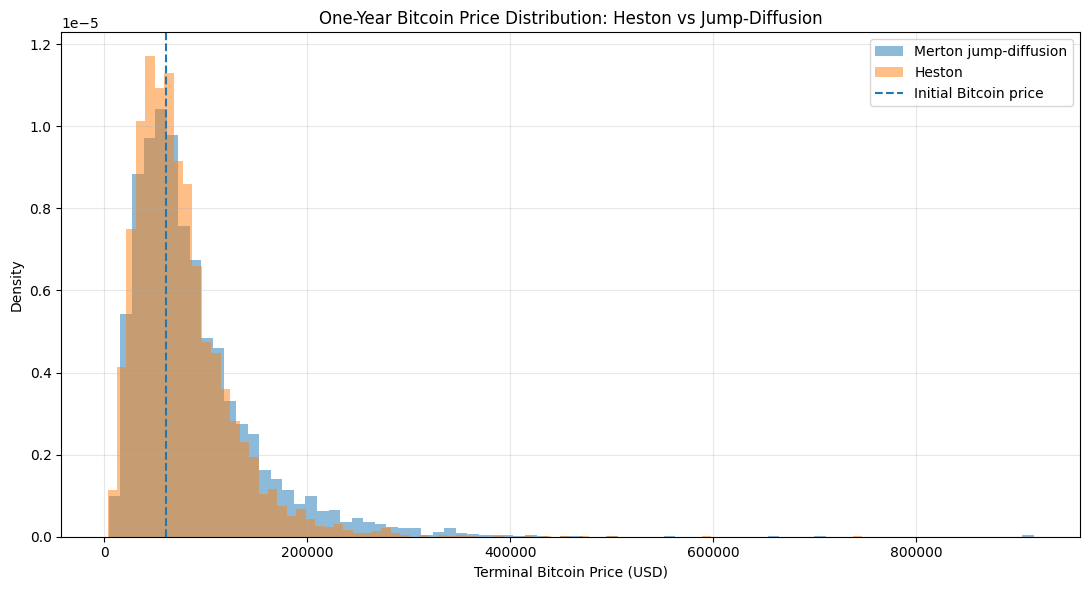

In [ ]:
plt.figure(figsize=(11, 6))

plt.hist(
    jump_terminal,
    bins=80,
    density=True,
    alpha=0.5,
    label="Merton jump-diffusion"
)

plt.hist(
    heston_terminal,
    bins=80,
    density=True,
    alpha=0.5,
    label="Heston"
)

plt.axvline(
    INITIAL_PRICE,
    linestyle="--",
    label="Initial Bitcoin price"
)

plt.title("One-Year Bitcoin Price Distribution: Heston vs Jump-Diffusion")
plt.xlabel("Terminal Bitcoin Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
percentiles = [1, 5, 10, 25, 50]

percentile_comparison = pd.DataFrame({
    "Percentile": percentiles,
    "Jump Diffusion": [
        np.percentile(jump_terminal, p)
        for p in percentiles
    ],
    "Heston": [
        np.percentile(heston_terminal, p)
        for p in percentiles
    ]
})

percentile_comparison

,Percentile,Jump Diffusion,Heston
0,1,15356.563954,12202.281959
1,5,23844.792798,21951.020023
2,10,30427.021279,28806.624599
3,25,46183.824692,43532.648685
4,50,71021.474233,65324.322202


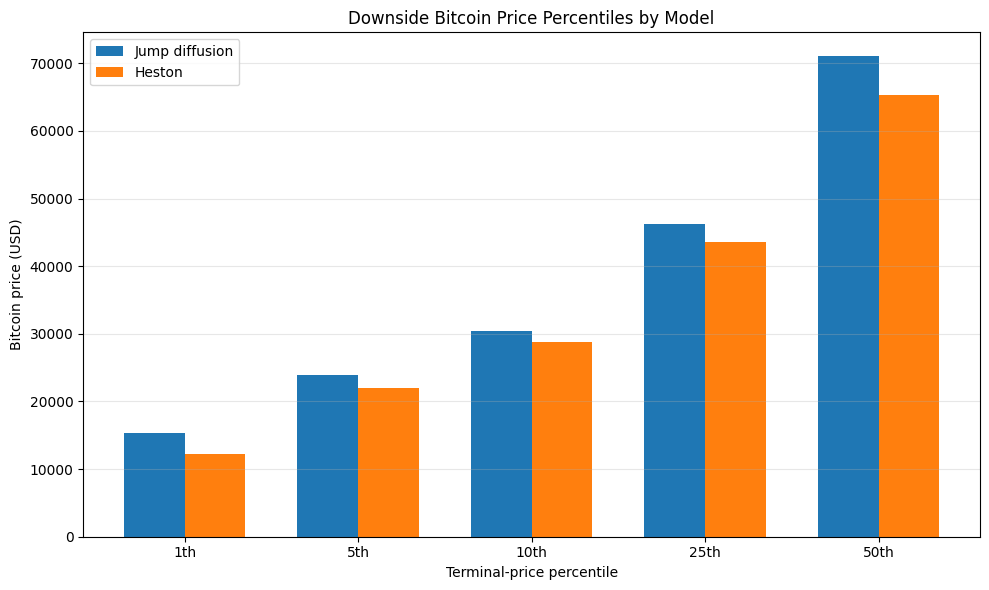

In [13]:
x = np.arange(len(percentiles))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    percentile_comparison["Jump Diffusion"],
    width,
    label="Jump diffusion"
)

plt.bar(
    x + width / 2,
    percentile_comparison["Heston"],
    width,
    label="Heston"
)

plt.xticks(
    x,
    [f"{p}th" for p in percentiles]
)

plt.xlabel("Terminal-price percentile")
plt.ylabel("Bitcoin price (USD)")
plt.title("Downside Bitcoin Price Percentiles by Model")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
LOAN_AMOUNT = 100_000_000
INITIAL_COLLATERAL = 150_000_000
LIQUIDATION_HAIRCUT = 0.10

In [15]:
jump_collateral = (
    INITIAL_COLLATERAL
    * jump_terminal
    / INITIAL_PRICE
)

heston_collateral = (
    INITIAL_COLLATERAL
    * heston_terminal
    / INITIAL_PRICE
)

In [16]:
jump_ltv = LOAN_AMOUNT / jump_collateral
heston_ltv = LOAN_AMOUNT / heston_collateral

In [17]:
jump_recovery = (
    jump_collateral
    * (1 - LIQUIDATION_HAIRCUT)
)

heston_recovery = (
    heston_collateral
    * (1 - LIQUIDATION_HAIRCUT)
)

jump_lgd = np.clip(
    (LOAN_AMOUNT - jump_recovery)
    / LOAN_AMOUNT,
    0,
    1
)

heston_lgd = np.clip(
    (LOAN_AMOUNT - heston_recovery)
    / LOAN_AMOUNT,
    0,
    1
)

In [18]:
collateral_comparison = pd.DataFrame({
    "Metric": [
        "Mean collateral value",
        "5th percentile collateral",
        "1st percentile collateral",
        "Mean LTV",
        "Probability LTV exceeds 100%",
        "Mean LGD",
        "95th percentile LGD"
    ],
    "Jump Diffusion": [
        jump_collateral.mean(),
        np.percentile(jump_collateral, 5),
        np.percentile(jump_collateral, 1),
        jump_ltv.mean(),
        np.mean(jump_ltv > 1),
        jump_lgd.mean(),
        np.percentile(jump_lgd, 95)
    ],
    "Heston": [
        heston_collateral.mean(),
        np.percentile(heston_collateral, 5),
        np.percentile(heston_collateral, 1),
        heston_ltv.mean(),
        np.mean(heston_ltv > 1),
        heston_lgd.mean(),
        np.percentile(heston_lgd, 95)
    ]
})

collateral_comparison

,Metric,Jump Diffusion,Heston
0,Mean collateral value,2.177311e+08,1.877189e+08
1,5th percentile collateral,5.917595e+07,5.447615e+07
2,1st percentile collateral,3.811060e+07,3.028257e+07
3,Mean LTV,7.064476e-01,7.841730e-01
4,Probability LTV exceeds 100%,1.920000e-01,2.136000e-01
5,Mean LGD,6.993258e-02,8.174986e-02
6,95th percentile LGD,4.674164e-01,5.097146e-01
